In [2]:
# Cell 1 — Imports & Config
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import IPython.display as ipd

DATA_ROOT_COLAB   = Path("../data/mimii/fan/id_00")
SAMPLE_RATE = 16_000

train_normal   = sorted((DATA_ROOT_COLAB / "train/normal").glob("*.wav"))
test_normal    = sorted((DATA_ROOT_COLAB / "test/normal").glob("*.wav"))
test_abnormal  = sorted((DATA_ROOT_COLAB / "test/abnormal").glob("*.wav"))

print(f"train/normal  : {len(train_normal)} files")
print(f"test/normal   : {len(test_normal)} files")
print(f"test/abnormal : {len(test_abnormal)} files")

train/normal  : 860 files
test/normal   : 151 files
test/abnormal : 407 files


In [3]:
# Cell 2 — Load one example of each class & listen
y_normal,   sr = librosa.load(test_normal[0],   sr=SAMPLE_RATE)
y_abnormal, _  = librosa.load(test_abnormal[0], sr=SAMPLE_RATE)

print(f"Duration : {len(y_normal)/sr:.1f} s  |  Sample rate: {sr} Hz")
print(f"Samples  : {len(y_normal)}")

print("\n▶ Normal:")
ipd.display(ipd.Audio(y_normal, rate=sr))
print("▶ Abnormal:")
ipd.display(ipd.Audio(y_abnormal, rate=sr))

Duration : 10.0 s  |  Sample rate: 16000 Hz
Samples  : 160000

▶ Normal:


▶ Abnormal:


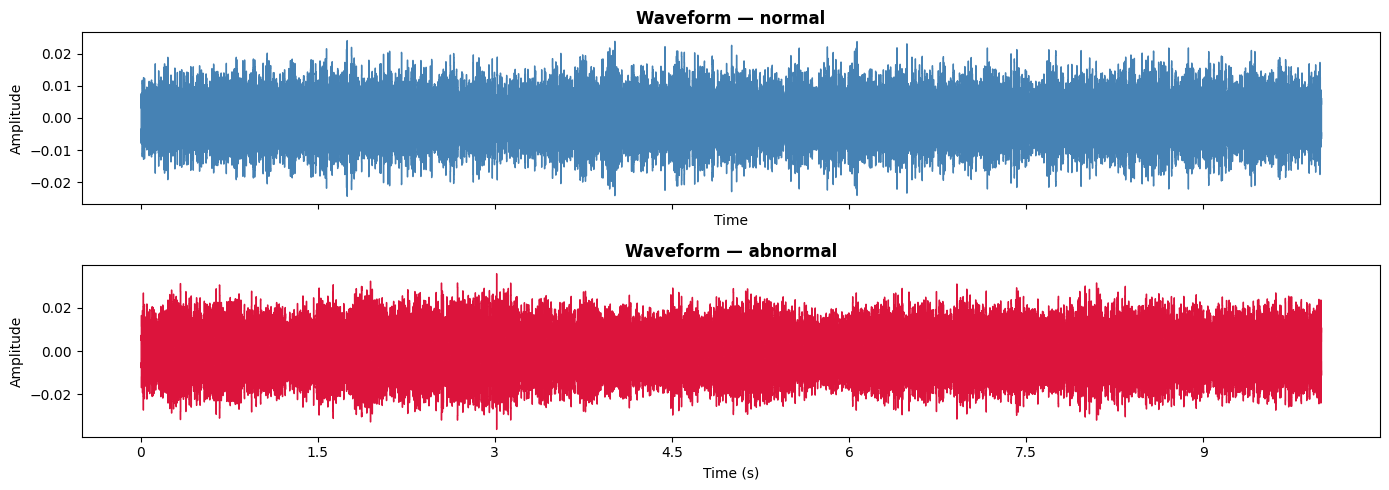

In [10]:
# Cell 3 — Waveform comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

librosa.display.waveshow(y_normal,   sr=sr, ax=axes[0], color="steelblue")
axes[0].set_title("Waveform — normal", fontweight="bold")
axes[0].set_ylabel("Amplitude")

librosa.display.waveshow(y_abnormal, sr=sr, ax=axes[1], color="crimson")
axes[1].set_title("Waveform — abnormal", fontweight="bold")
axes[1].set_ylabel("Amplitude")
axes[1].set_xlabel("Time (s)")

plt.tight_layout()
#plt.savefig("waveform_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

Spectrogram shape: (128, 313)  → (n_mels × time_frames)


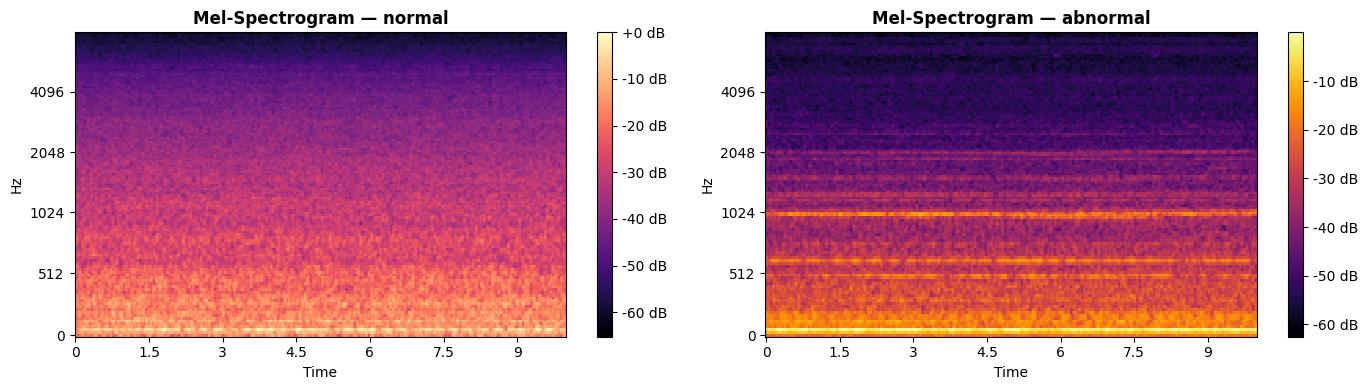

In [11]:
# Cell 4 — Mel-Spectrogram comparison
def compute_mel(y, sr, n_mels=128, fmax=8000):
    S  = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, fmax=fmax)
    return librosa.power_to_db(S, ref=np.max)   # dB-Skala: menschl. Hören ist logarithmisch

S_normal   = compute_mel(y_normal,   sr)
S_abnormal = compute_mel(y_abnormal, sr)

print(f"Spectrogram shape: {S_normal.shape}  → (n_mels × time_frames)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, S, title, cmap in zip(
    axes,
    [S_normal, S_abnormal],
    ["Mel-Spectrogram — normal", "Mel-Spectrogram — abnormal"],
    ["magma", "inferno"]
):
    img = librosa.display.specshow(S, sr=sr, x_axis="time",
                                   y_axis="mel", fmax=8000,
                                   ax=ax, cmap=cmap)
    ax.set_title(title, fontweight="bold")
    fig.colorbar(img, ax=ax, format="%+2.0f dB")

plt.tight_layout()
#plt.savefig("mel_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

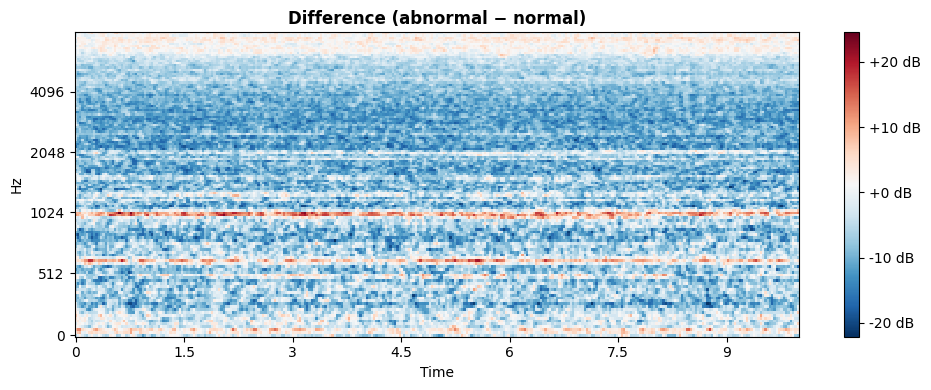

In [12]:
# Cell 5 — Difference Spectrogram
S_diff = S_abnormal - S_normal

fig, ax = plt.subplots(figsize=(10, 4))
img = librosa.display.specshow(S_diff, sr=sr, x_axis="time",
                                y_axis="mel", fmax=8000,
                                ax=ax, cmap="RdBu_r")
ax.set_title("Difference (abnormal − normal)",
             fontweight="bold")
fig.colorbar(img, ax=ax, format="%+2.0f dB")
plt.tight_layout()
#plt.savefig("mel_difference.png", dpi=150, bbox_inches="tight")
plt.show()

── RMS Energy ─────────────────────────────────────
  Normal    mean: 0.00601  std: 0.00034
  Abnormal  mean: 0.00765  std: 0.00191


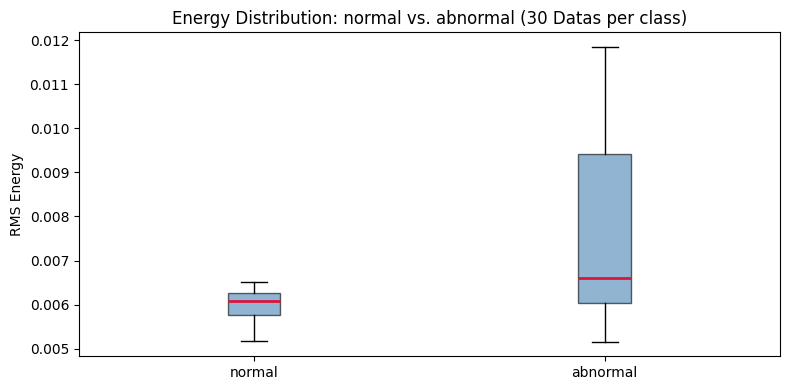

In [13]:
# Cell 6 — Signal statistics across multiple files
def rms_energy(filepath):
    y, _ = librosa.load(filepath, sr=SAMPLE_RATE)
    return np.sqrt(np.mean(y**2))

# Sample 30 files from each class for speed
import random
random.seed(42)
sample_n = random.sample(test_normal,   min(30, len(test_normal)))
sample_a = random.sample(test_abnormal, min(30, len(test_abnormal)))

rms_normal   = [rms_energy(f) for f in sample_n]
rms_abnormal = [rms_energy(f) for f in sample_a]

print("── RMS Energy ─────────────────────────────────────")
print(f"  Normal    mean: {np.mean(rms_normal):.5f}  std: {np.std(rms_normal):.5f}")
print(f"  Abnormal  mean: {np.mean(rms_abnormal):.5f}  std: {np.std(rms_abnormal):.5f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot([rms_normal, rms_abnormal], tick_labels=["normal", "abnormal"],
           patch_artist=True,
           boxprops=dict(facecolor="steelblue", alpha=0.6),
           medianprops=dict(color="crimson", linewidth=2))
ax.set_ylabel("RMS Energy")
ax.set_title("Energy Distribution: normal vs. abnormal (30 Datas per class)")
plt.tight_layout()
#plt.savefig("rms_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# --- 7. Basic statistics ---
print("\n Signal statistics")
for label, y in [("Normal  ", y_normal), ("Abnormal", y_abnormal)]:
    rms = np.sqrt(np.mean(y**2))
    print(f"{label} | RMS: {rms:.4f} | MAX: {np.max(np.abs(y)):.4f}"
         f" | Std: {np.std(y):.4f}")


 Signal statistics
Normal   | RMS: 0.0061 | MAX: 0.0242 | Std: 0.0061
Abnormal | RMS: 0.0100 | MAX: 0.0360 | Std: 0.0100
